# Movie & TV Show Popularity Analytics Dashboard 

## i. Link Pendukung
Tableu : https://public.tableau.com/views/Milestone2_17805819871920/Story1?:language=en-US&:sid=&:display_count=n&:origin=viz_share_link

# ii. Identifikasi Masalah

## 1. Topik Permasalahan

Analisis faktor-faktor yang memengaruhi popularitas dan penilaian film atau TV show berdasarkan genre, bahasa, tanggal rilis, jumlah vote, dan rating pengguna.

## 2. Problem Statement

Mengetahui karakteristik film dan TV show yang paling populer serta faktor-faktor yang memengaruhi popularitas dan penilaian audiens berdasarkan genre, bahasa, tanggal rilis, dan metrik evaluasi pengguna.

Specific    : Mengidentifikasi faktor yang memengaruhi popularitas film dan TV show berdasarkan genre, bahasa, dan tahun rilis.

Measurable  : Mengukur rata-rata Popularity per genre, jumlah konten per bahasa, serta korelasi Popularity dan Vote Count

Achievable  : Analisis dilakukan pada 9.826 data yang tersedia.

Relevant    : Membantu memahami karakteristik konten yang paling diminati audiens.

Time-Bound  : Analisis dilakukan pada data rilis hingga 2024 untuk memperoleh insight tren popularitas terkini.


## 3. Latar Belakang

Banyaknya pilihan film dan TV show di platform streaming membuat penting untuk memahami karakteristik konten yang paling diminati oleh penonton. Analisis ini dapat membantu content creator dan produser dalam memahami tren serta preferensi penonton.

## 4. Penjabaran Masalah

1. Apa genre yang paling populer berdasarkan nilai Popularity?
2. Genre Mana yang Memiliki Jumlah Film atau TV Show Terbanyak?
3. Kapan film atau TV show dengan tingkat popularitas tertinggi dirilis?
4. Di mana (berdasarkan Original Language) sebagian besar konten populer diproduksi?
5. Mengapa beberapa genre memiliki tingkat popularitas yang lebih tinggi dibandingkan genre lainnya?
6. Apakah ada perbedaan antara popularity pada genre action dan genre adventure?

# iii. Data Loading

## 1. Import Libraries

In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import ttest_ind

## 2. Membaca File Dataset (.csv)

Sumber dataset : https://www.kaggle.com/datasets/nalisha/netflix-movies-and-tv-shows-data-analysis

In [4]:
# Membaca file CSV
df = pd.read_csv(
    "mymoviedb.csv",
    encoding="utf-8",
    engine="python"
)

## 3. Eksplorasi Data Sederhana

### 3.1. Menampilkan 5 Data Teratas

In [5]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


### 3.2. Menampilkan Dimensi Dataset (Baris,Kolom)

In [6]:
df.shape

(9837, 9)

### 3.3. Menampilkan Informasi Dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


### 3.4. Menampilkan Missing Value Untuk Setiap Kolom

In [8]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

### 3.5. Menampilkan Jumlah Data Duplikat

In [11]:
df.duplicated().sum()

np.int64(0)

# iv. Data Cleaning

## 1. Menghapus Baris Yang Memiliki Missing Value

Baris dihapus karena data yang memiliki missing value hanya sedikit, jadi tidak akan berpengaruh terhadap proses analisis

In [13]:
df = df.dropna()

Mengecek kembali missing value pada dataset

In [14]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

## 2. Menghapus Kolom Yang Tidak Digunakan

In [15]:
df = df.drop(columns=['Poster_Url'])

## 3. Mengubah Tipe Data Tanggal

In [16]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

## 4. Mengubah Tipe Data Numerik

In [17]:
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'])
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'])

## 5. Membuat Kolom Tahun Rilis

In [26]:
df['Release_Year'] = df['Release_Date'].dt.year

## 6. Menjabarkan Data Genre

Proses ini dilakukan karena dalam 1 baris bisa memiliki lebih dari 1 genre

In [53]:
# Pisahkan genre berdasarkan koma
df['Genre'] = df['Genre'].str.split(',')

# Hilangkan spasi di awal/akhir nama genre
df['Genre'] = df['Genre'].apply(
    lambda x: [genre.strip() for genre in x]
)

# Pecah menjadi beberapa baris
df_genre = df.explode('Genre')

df_genre.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,Action,2021
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,Adventure,2021
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,Science Fiction,2021
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,Crime,2022
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,Mystery,2022


Mengecek kembali informasi dataset

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9826 non-null   datetime64[ns]
 1   Title              9826 non-null   object        
 2   Overview           9826 non-null   object        
 3   Popularity         9826 non-null   float64       
 4   Vote_Count         9826 non-null   int64         
 5   Vote_Average       9826 non-null   float64       
 6   Original_Language  9826 non-null   object        
 7   Genre              9826 non-null   object        
 8   Release_Year       9826 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(4)
memory usage: 729.3+ KB


## 7. Export Data Cleaning

In [62]:
df_genre.to_csv('data_clean.csv', index=False,encoding='utf-8')

# v. Analis dan Perhitungan

## 1. Apa genre yang paling populer berdasarkan nilai Popularity?

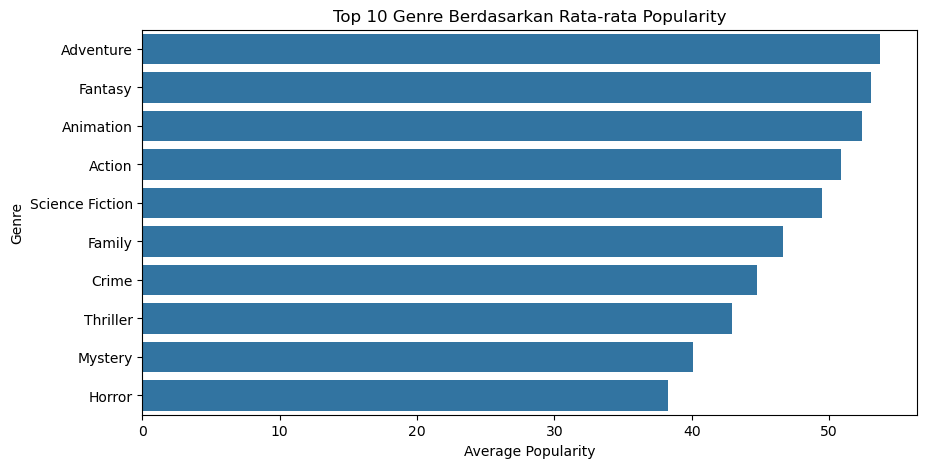

In [54]:
genre_popularity = df_genre.groupby('Genre')['Popularity'] \
                           .mean() \
                           .sort_values(ascending=False) \
                           .head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=genre_popularity.values,
    y=genre_popularity.index
)

plt.title('Top 10 Genre Berdasarkan Rata-rata Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.show()

### Insight

Genre Adventure memiliki rata-rata Popularity tertinggi, diikuti oleh Fantasy dan Animation. Hal ini menunjukkan bahwa konten bertema petualangan dan fantasi cenderung lebih diminati dan menarik perhatian audiens dibandingkan genre lainnya.

## 2. Genre Mana yang Memiliki Jumlah Film atau TV Show Terbanyak?

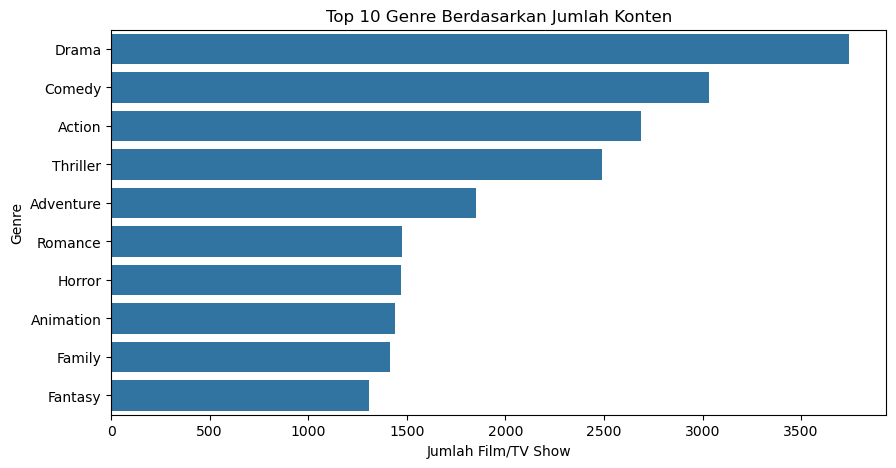

In [64]:
genre_count = df_genre['Genre'] \
                .value_counts() \
                .head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=genre_count.values,
    y=genre_count.index
)

plt.title('Top 10 Genre Berdasarkan Jumlah Konten')
plt.xlabel('Jumlah Film/TV Show')
plt.ylabel('Genre')
plt.show()

### Insight

Genre Drama, Comedy, dan Action memiliki jumlah film atau TV show terbanyak dalam dataset. Hal ini menunjukkan bahwa genre tersebut merupakan kategori yang paling banyak diproduksi dan tersedia bagi penonton dibandingkan genre lainnya.

## 3. Kapan film atau TV show dengan tingkat popularitas tertinggi dirilis?

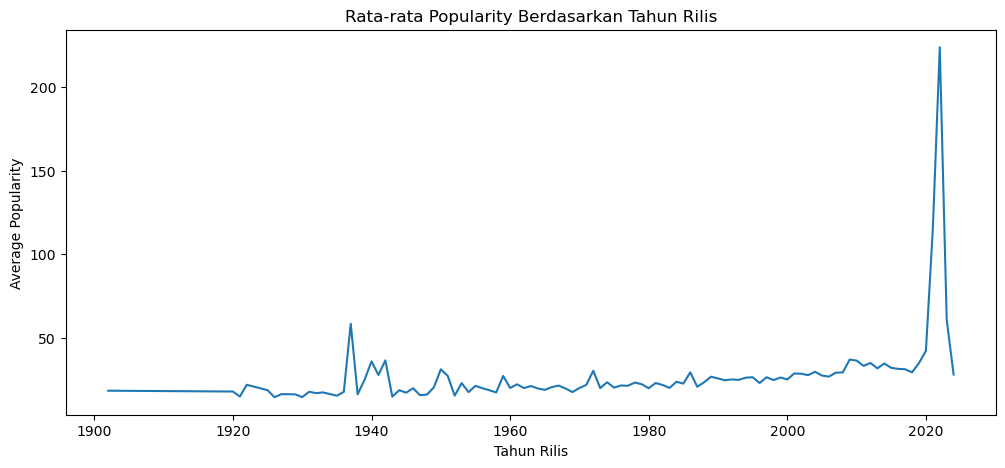

In [56]:
year_popularity = df.groupby('Release_Year')['Popularity'] \
                    .mean()

plt.figure(figsize=(12,5))
plt.plot(
    year_popularity.index,
    year_popularity.values
)

plt.title('Rata-rata Popularity Berdasarkan Tahun Rilis')
plt.xlabel('Tahun Rilis')
plt.ylabel('Average Popularity')
plt.show()

### Insight

Rata-rata Popularity mengalami peningkatan pada tahun-tahun terbaru dan mencapai puncaknya sekitar tahun 2022. Hal ini menunjukkan bahwa konten yang dirilis pada periode tersebut memperoleh perhatian audiens yang lebih tinggi dibandingkan tahun-tahun sebelumnya.

## 4. Di mana (berdasarkan Original Language) sebagian besar konten populer diproduksi?

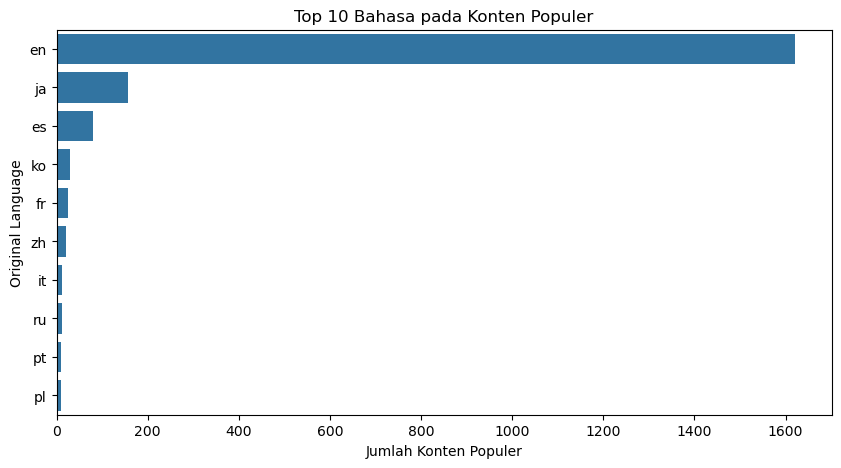

In [57]:
popular_content = df[
    df['Popularity'] > df['Popularity'].mean()
]

language_count = popular_content['Original_Language'] \
                    .value_counts() \
                    .head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=language_count.values,
    y=language_count.index
)

plt.title('Top 10 Bahasa pada Konten Populer')
plt.xlabel('Jumlah Konten Populer')
plt.ylabel('Original Language')
plt.show()

### Insight

Bahasa Inggris memiliki jumlah konten populer terbanyak, diikuti oleh Jepang, Spanyol, Korea, dan Prancis. Hal ini menunjukkan bahwa konten berbahasa Inggris masih mendominasi industri hiburan global, sementara konten dari Jepang, Korea, Spanyol, dan Prancis juga memiliki daya tarik yang kuat dan berhasil menjangkau audiens internasional.

## 5. Mengapa beberapa genre memiliki tingkat popularitas yang lebih tinggi dibandingkan genre lainnya?

In [65]:
genre_stats = df_genre.groupby('Genre')['Popularity'].agg([
    'mean',
    'median',
    'std',
    'min',
    'max',
    'count'
]).sort_values(
    by='mean',
    ascending=False
)

genre_stats.head(5)

,mean,median,std,min,max,count
Genre,,,,,,
Adventure,53.742888,25.5140,154.856942,13.359,5083.954,1853
Fantasy,53.081342,25.9965,116.560193,13.357,2402.201,1308
Animation,52.427663,27.4270,111.041582,13.360,2402.201,1438
Action,50.890133,24.5175,144.361159,13.359,5083.954,2686
Science Fiction,49.511334,24.6980,162.040301,13.354,5083.954,1273


### Insight

Genre Adventure, Fantasy, dan Animation memiliki popularitas lebih tinggi karena memiliki rata-rata Popularity yang besar dan beberapa judul dengan tingkat popularitas yang sangat tinggi, sehingga meningkatkan rata-rata popularitas genre secara keseluruhan.

## 6. Apakah ada perbedaan antara popularity pada genre action dan genre adventure?

Data dipisahkan menjadi dua kelompok:

- Genre Action
- Genre Adventure

Kedua data ini akan dibandingkan rata-rata Popularity-nya.

In [66]:
action = df_genre[df_genre['Genre'] == 'Action']['Popularity']

adventure = df_genre[df_genre['Genre'] == 'Adventure']['Popularity']

Melihat gambaran awal data seperti:

- jumlah data (count)
- rata-rata (mean)
- standar deviasi (std)
- nilai minimum dan maksimum

sebelum dilakukan pengujian statistik.

In [69]:
print("Action")
print(action.describe())

print("\nAdventure")
print(adventure.describe())

Action
count    2686.000000
mean       50.890133
std       144.361159
min        13.359000
25%        17.591250
50%        24.517500
75%        43.561250
max      5083.954000
Name: Popularity, dtype: float64

Adventure
count    1853.000000
mean       53.742888
std       154.856942
min        13.359000
25%        17.755000
50%        25.514000
75%        48.086000
max      5083.954000
Name: Popularity, dtype: float64


Melakukan Independent Two Sample T-Test

In [70]:
# Fungsi ttest_ind() digunakan untuk membandingkan rata-rata dua kelompok independen.
t_stat, p_value = ttest_ind(
    action,
    adventure,
    equal_var=False  # Welch's t-test
)

print("T-statistic :", t_stat)
print("P-value :", p_value)

T-statistic : -0.6270118806636888
P-value : 0.530689145963248


Interpretasi Hasil

In [73]:
# mendefinisikan nilai alpha
alpha = 0.05

if p_value < 0.05:
    print("Tolak H0")
    print("Terdapat perbedaan signifikan antara Popularity genre Action dan Adventure")
else:
    print("Gagal menolak H0")
    print("Tidak terdapat perbedaan signifikan antara Popularity genre Action dan Adventure")

Gagal menolak H0
Tidak terdapat perbedaan signifikan antara Popularity genre Action dan Adventure


Visualisasi Pendukung

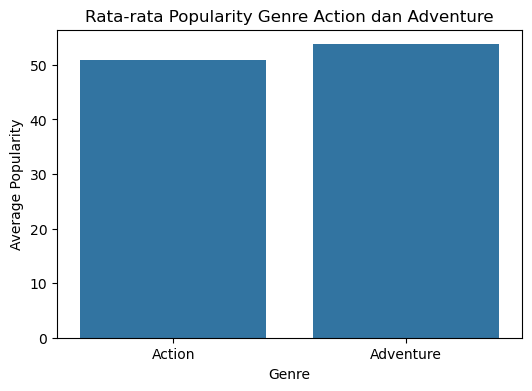

In [80]:
mean_popularity = df_genre[df_genre['Genre'].isin(['Action', 'Adventure'])] \
                    .groupby('Genre')['Popularity'] \
                    .mean() \
                    .reset_index()

plt.figure(figsize=(6,4))

sns.barplot(
    data=mean_popularity,
    x='Genre',
    y='Popularity'
)

plt.title('Rata-rata Popularity Genre Action dan Adventure')
plt.xlabel('Genre')
plt.ylabel('Average Popularity')

plt.show()

### Insight

Berdasarkan hasil Independent Two Sample T-Test, tidak terdapat perbedaan yang signifikan antara rata-rata Popularity genre Action dan Adventure (p-value > 0,05). Meskipun genre Adventure memiliki rata-rata Popularity yang sedikit lebih tinggi, perbedaan tersebut tidak cukup besar secara statistik sehingga kedua genre dapat dianggap memiliki tingkat popularitas yang relatif sama.

# vi. Pengambilan Keputusan

## 1. Kesimpulan

Berdasarkan hasil analisis, genre, bahasa produksi, tahun rilis, dan keterlibatan audiens merupakan faktor yang berkaitan dengan popularitas film dan TV show. Genre Adventure menjadi yang paling populer, konten berbahasa Inggris mendominasi, dan tahun 2022 menjadi periode dengan tingkat popularitas tertinggi. Insight ini dapat menjadi acuan bagi produsen film maupun content creator dalam menentukan strategi konten yang lebih sesuai dengan minat audiens.

## 2. Action Recommendation

1. Memprioritaskan produksi dan pengembangan konten pada genre Adventure, Fantasy, dan Animation karena ketiga genre tersebut memiliki tingkat popularitas tertinggi dan berpotensi menjangkau audiens yang lebih luas.
2. Mengadopsi elemen storytelling dari genre dengan penilaian tinggi, seperti History, War, dan Music, untuk meningkatkan kualitas narasi, kedalaman cerita, dan pengalaman menonton sehingga dapat meningkatkan apresiasi audiens.
3. Menganalisis karakteristik film dan TV show populer yang dirilis pada tahun 2022, seperti tema, alur cerita, format konten, maupun strategi promosi, untuk dijadikan referensi dalam pengembangan konten baru yang lebih relevan dengan preferensi penonton saat ini.
4. Bagi content creator, memperbanyak pembahasan, ulasan, dan konten rekomendasi yang berkaitan dengan genre Adventure, Fantasy, dan Animation, serta memanfaatkan momentum film atau serial yang sedang tren untuk meningkatkan engagement audiens.
5. Memanfaatkan dominasi konten berbahasa Inggris sebagai pasar utama, sekaligus mengeksplorasi konten dari Jepang, Korea, Spanyol, dan Prancis yang menunjukkan potensi popularitas tinggi dan memiliki basis penggemar yang terus berkembang.
6. Meningkatkan interaksi dan partisipasi audiens, seperti mendorong pemberian rating, vote, komentar, dan diskusi komunitas, karena tingginya Vote Count cenderung berhubungan dengan meningkatnya Popularity suatu film atau TV show.